In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *
from scipy.special import expit
from scipy.stats import ttest_rel, wilcoxon
from pygam import LogisticGAM
from sklearn.linear_model import LogisticRegression
from interpret.glassbox import ExplainableBoostingClassifier
import pymc as pm
import pytensor.tensor as pt


In [12]:
DATA_PATH = "../data/train.csv"

MODEL_PATHS = {
    "lr": "../models/lr_model.pkl",
    "blr": "../models/blr_model.pkl",
    "gam": "../models/gam_model.pkl",
    "ebm": "../models/ebm_model.pkl"
}

SCALER_PATH = "../models/scaler.pkl"

In [13]:
print("Dataset:", os.path.exists(DATA_PATH))

for model_name, path in MODEL_PATHS.items():
    print(model_name, os.path.exists(path))

print("Scaler:", os.path.exists(SCALER_PATH))

Dataset: True
lr True
blr True
gam True
ebm True
Scaler: True


In [14]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

In [15]:

X_test_scaled = X_test.copy()

In [16]:
lr_model = joblib.load(MODEL_PATHS["lr"])
blr_model = joblib.load(MODEL_PATHS["blr"])
gam_model = joblib.load(MODEL_PATHS["gam"])
ebm_model = joblib.load(MODEL_PATHS["ebm"])

print("All models loaded successfully.")

print("LR:", type(lr_model))
print("BLR:", type(blr_model))
print("GAM:", type(gam_model))
print("EBM:", type(ebm_model))

All models loaded successfully.
LR: <class 'sklearn.linear_model._logistic.LogisticRegression'>
BLR: <class 'dict'>
GAM: <class 'pygam.pygam.LogisticGAM'>
EBM: <class 'interpret.glassbox._ebm._ebm.ExplainableBoostingClassifier'>


In [ ]:

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

In [ ]:

blr_columns = blr_model.get(
    "columns",
    X_test_scaled.columns.tolist()
)

X_test_blr = X_test_scaled.reindex(
    columns=blr_columns
)

X_test_blr = X_test_blr.apply(
    pd.to_numeric,
    errors="coerce"
).astype(float)

alpha_mean = float(
    np.asarray(
        blr_model["alpha_mean"]
    ).squeeze()
)

beta_mean = np.asarray(
    blr_model["beta_mean"],
    dtype=float
).reshape(-1)

if X_test_blr.isna().any().any():
    print("Warning: Missing values found after numeric conversion.")
    print(
        X_test_blr.columns[
            X_test_blr.isna().any()
        ].tolist()
    )

    X_test_blr = X_test_blr.fillna(0)

print("BLR X_test shape:", X_test_blr.shape)
print("BLR beta shape:", beta_mean.shape)

if X_test_blr.shape[1] != beta_mean.shape[0]:
    raise ValueError(
        f"Feature mismatch: X_test has "
        f"{X_test_blr.shape[1]} features, but BLR has "
        f"{beta_mean.shape[0]} coefficients."
    )

blr_logits = (
    alpha_mean
    + X_test_blr.to_numpy(dtype=float) @ beta_mean
)

y_prob_blr = expit(
    np.asarray(
        blr_logits,
        dtype=float
    )
)

print(
    "BLR probabilities generated:",
    y_prob_blr.shape
)

BLR X_test shape: (118799, 23)
BLR beta shape: (23,)
BLR probabilities generated: (118799,)


In [ ]:

y_prob_gam = gam_model.predict_proba(
    X_test_scaled
)

y_prob_gam = np.asarray(
    y_prob_gam,
    dtype=float
).ravel()


y_prob_ebm = ebm_model.predict_proba(
    X_test_scaled
)[:, 1]

y_prob_ebm = np.asarray(
    y_prob_ebm,
    dtype=float
).ravel()

print("All probabilities generated successfully.")

All probabilities generated successfully.


In [20]:
print("LR:", y_prob_lr.shape)
print("BLR:", y_prob_blr.shape)
print("GAM:", y_prob_gam.shape)
print("EBM:", y_prob_ebm.shape)

LR: (118799,)
BLR: (118799,)
GAM: (118799,)
EBM: (118799,)


In [21]:
probability_results = {
    "LR": y_prob_lr,
    "BLR": y_prob_blr,
    "GAM": y_prob_gam,
    "EBM": y_prob_ebm
}

for model_name, probabilities in probability_results.items():

    print(
        f"{model_name}: "
        f"shape = {probabilities.shape}, "
        f"min = {probabilities.min():.4f}, "
        f"max = {probabilities.max():.4f}, "
        f"valid = {np.isfinite(probabilities).all()}"
    )

LR: shape = (118799,), min = 0.0000, max = 0.9998, valid = True
BLR: shape = (118799,), min = 0.0000, max = 0.9998, valid = True
GAM: shape = (118799,), min = 0.0000, max = 1.0000, valid = True
EBM: shape = (118799,), min = 0.0000, max = 1.0000, valid = True


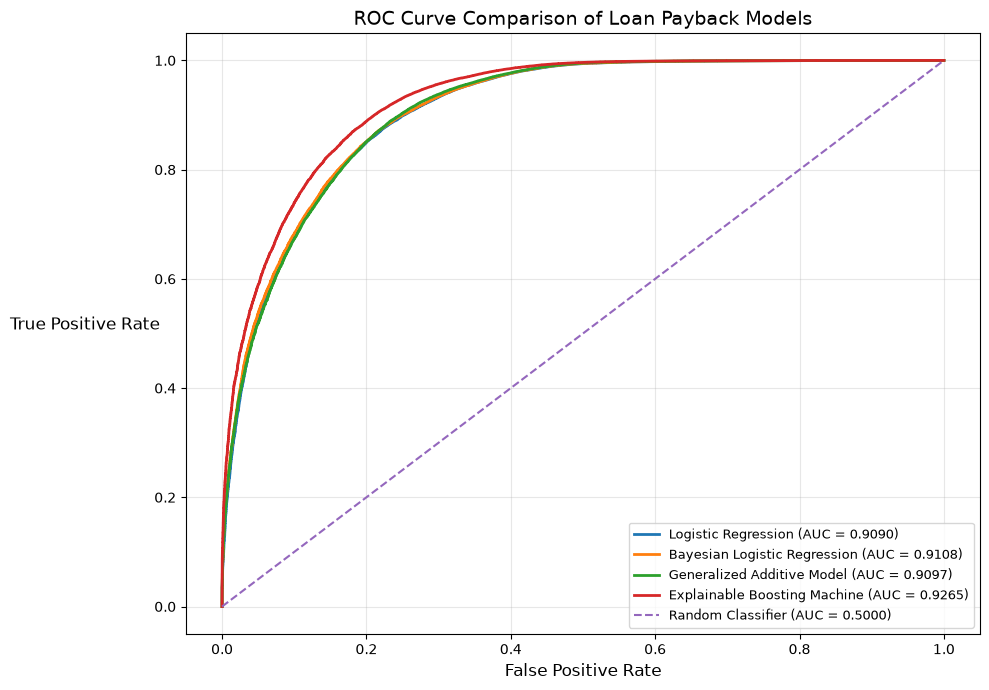

In [ ]:

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Bayesian Logistic Regression": y_prob_blr,
    "Generalized Additive Model": y_prob_gam,
    "Explainable Boosting Machine": y_prob_ebm
}

plt.figure(figsize=(10, 7))

for model_name, y_probability in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    auc_score = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    rotation=0,
    labelpad=50,
    fontsize=12
)

plt.title(
    "ROC Curve Comparison of Loan Payback Models",
    fontsize=14
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/all_models_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Bayesian Logistic Regression": y_prob_blr,
    "Generalized Additive Model": y_prob_gam,
    "Explainable Boosting Machine": y_prob_ebm
}

for model_name, probabilities in model_probabilities.items():

    probabilities = np.asarray(
        probabilities,
        dtype=float
    ).ravel()

    print(
        f"{model_name}: "
        f"shape={probabilities.shape}, "
        f"min={probabilities.min():.4f}, "
        f"max={probabilities.max():.4f}"
    )

Logistic Regression: shape=(118799,), min=0.0000, max=0.9998
Bayesian Logistic Regression: shape=(118799,), min=0.0000, max=0.9998
Generalized Additive Model: shape=(118799,), min=0.0000, max=1.0000
Explainable Boosting Machine: shape=(118799,), min=0.0000, max=1.0000


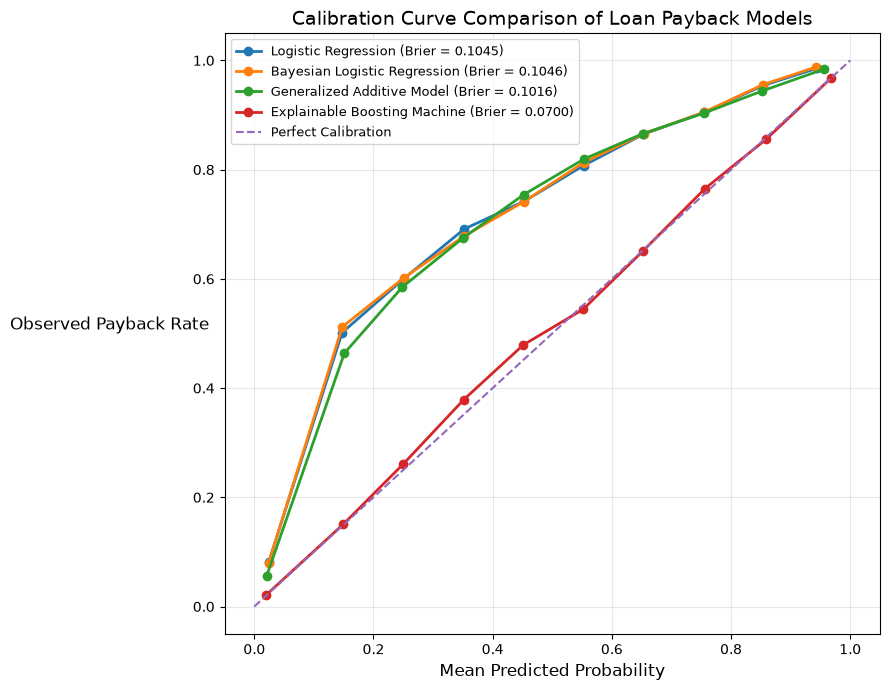

In [ ]:

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Bayesian Logistic Regression": y_prob_blr,
    "Generalized Additive Model": y_prob_gam,
    "Explainable Boosting Machine": y_prob_ebm
}

plt.figure(figsize=(9, 7))

for model_name, probabilities in model_probabilities.items():

    probabilities = np.asarray(
        probabilities,
        dtype=float
    ).ravel()

    fraction_of_positives, mean_predicted_probability = (
        calibration_curve(
            y_test,
            probabilities,
            n_bins=10,
            strategy="uniform"
        )
    )

    brier_score = brier_score_loss(
        y_test,
        probabilities
    )

    plt.plot(
        mean_predicted_probability,
        fraction_of_positives,
        marker="o",
        linewidth=2,
        label=(
            f"{model_name} "
            f"(Brier = {brier_score:.4f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability",
    fontsize=12
)

plt.ylabel(
    "Observed Payback Rate",
    rotation=0,
    labelpad=60,
    fontsize=12
)

plt.title(
    "Calibration Curve Comparison of Loan Payback Models",
    fontsize=14
)

plt.legend(
    loc="upper left",
    fontsize=9
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/all_models_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

lr_auc = np.array([
    0.916431,
    0.919765,
    0.918104,
    0.919031,
    0.918422
])

gam_auc = np.array([
    0.923473,
    0.927223,
    0.926768,
    0.926976,
    0.927222
])

fold_comparison = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "LR ROC-AUC": lr_auc,
    "GAM ROC-AUC": gam_auc,
    "Difference": gam_auc - lr_auc
})

display(fold_comparison)

t_stat, p_value = ttest_rel(
    gam_auc,
    lr_auc
)

print("LR Mean ROC-AUC:", round(lr_auc.mean(), 6))
print("GAM Mean ROC-AUC:", round(gam_auc.mean(), 6))
print(
    "Mean Difference:",
    round((gam_auc - lr_auc).mean(), 6)
)

print("t-statistic:", round(t_stat, 6))
print("p-value:", p_value)

if p_value < 0.05:
    print(
        "Conclusion: The difference is statistically significant."
    )
else:
    print(
        "Conclusion: The difference is not statistically significant."
    )

,Fold,LR ROC-AUC,GAM ROC-AUC,Difference
0,1,0.916431,0.923473,0.007042
1,2,0.919765,0.927223,0.007458
2,3,0.918104,0.926768,0.008664
3,4,0.919031,0.926976,0.007945
4,5,0.918422,0.927222,0.008800


LR Mean ROC-AUC: 0.918351
GAM Mean ROC-AUC: 0.926332
Mean Difference: 0.007982
t-statistic: 23.568869
p-value: 1.9213302896123382e-05
Conclusion: The difference is statistically significant.
